Saving bmw_global_sales_dataset.csv to bmw_global_sales_dataset (28).csv


/tmp/ipykernel_8906/1729532623.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelos_labels, y=acuracias, ax=ax[0], palette='Blues_d')



Relatório final de acurácia:
Decision Tree: 81.50%
Random Forest: 82.00%


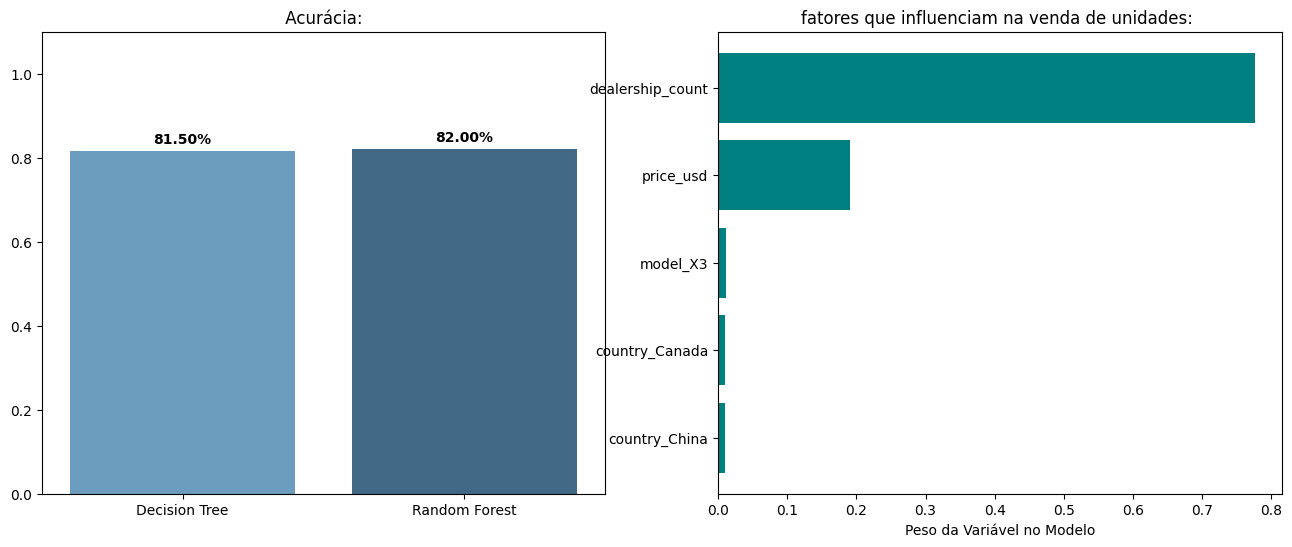

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib


uploaded = files.upload()
df = pd.read_csv("bmw_global_sales_dataset.csv")


limite = df['units_sold'].median()
df['target'] = (df['units_sold'] > limite).astype(int)


X = df.drop(["target", "units_sold"], axis=1)
y = df["target"]


X = pd.get_dummies(X)


X = X.loc[:, X.nunique() > 1]
corr_target = X.corrwith(y)
X = X.loc[:, abs(corr_target) > 0.05]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


modelo_dt = DecisionTreeClassifier(random_state=42)
modelo_rf = RandomForestClassifier(n_estimators=300, random_state=42)

modelo_dt.fit(X_train, y_train)
modelo_rf.fit(X_train, y_train)


acc_dt = accuracy_score(y_test, modelo_dt.predict(X_test))
acc_rf = accuracy_score(y_test, modelo_rf.predict(X_test))


fig, ax = plt.subplots(1, 2, figsize=(16, 6))


modelos_labels = ['Decision Tree', 'Random Forest']
acuracias = [acc_dt, acc_rf]
sns.barplot(x=modelos_labels, y=acuracias, ax=ax[0], palette='Blues_d')
ax[0].set_title(' Acurácia: ')
ax[0].set_ylim(0, 1.1)
for i, v in enumerate(acuracias):
    ax[0].text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

importances = modelo_rf.feature_importances_
indices = np.argsort(importances)[-10:]
features = X.columns

ax[1].barh(range(len(indices)), importances[indices], color='teal', align='center')
ax[1].set_yticks(range(len(indices)))
ax[1].set_yticklabels([features[i] for i in indices])
ax[1].set_title('fatores que influenciam na venda de unidades: ')
ax[1].set_xlabel('Peso da Variável no Modelo')


print(f"\nRelatório final de acurácia:\nDecision Tree: {acc_dt:.2%}\nRandom Forest: {acc_rf:.2%}")

